This notebook produces Figure 1, the basemap for the Superstition Hills/Imperial Valley region of interest (ROI).
<br>
<br>
I used predefined colors from here: https://docs.generic-mapping-tools.org/6.2/gmtcolors.html
<br>
<br>
For this notebook (and this notebook only), use the "pygmt" conda environment as the Python kernel. 
***

In [4]:
# import the dependencies 
import pygmt
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import fiona

In [8]:
# In order to have the corner coordinates for the next code cell, 
# we have to geolocate the corner coordinates to lat/lon from radar coordinates.

# this folder is named 'cropped_startX_startY_dx_dy' so we know what dx and dy are from the name itself:
dx = 9000
dy = 1575

# Now convert radar coordinates to lat/lon, for each corner.
print('TOP RIGHT CORNER.')
! gdallocationinfo lat.rdr.full 0 0 
! gdallocationinfo lon.rdr.full 0 0 
print('TOP LEFT CORNER.')
! gdallocationinfo lat.rdr.full {dx-1} 0 
! gdallocationinfo lon.rdr.full {dx-1} 0  
print('BOTTOM LEFT CORNER.')
! gdallocationinfo lat.rdr.full {dx-1} {dy-1} 
! gdallocationinfo lon.rdr.full {dx-1} {dy-1}   
print('BOTTOM RIGHT CORNER.')
! gdallocationinfo lat.rdr.full 0 {dy-1}
! gdallocationinfo lon.rdr.full 0 {dy-1}    

TOP RIGHT CORNER.
ERROR 4: `lat.rdr.full' not recognized as a supported file format.
Report:
  Location: (0P,0L)
  Band 1:
    Value: -115.469374620676
TOP LEFT CORNER.
ERROR 4: `lat.rdr.full' not recognized as a supported file format.
Report:
  Location: (8999P,0L)
  Band 1:
    Value: -115.833826661758
BOTTOM LEFT CORNER.
ERROR 4: `lat.rdr.full' not recognized as a supported file format.
Report:
  Location: (8999P,1574L)
  Band 1:
    Value: -115.875714564935
BOTTOM RIGHT CORNER.
ERROR 4: `lat.rdr.full' not recognized as a supported file format.
Report:
  Location: (0P,1574L)
  Band 1:
    Value: -115.512581993216


In [9]:
# define the four corners of the ROI in lat/lon coordinates
SH=np.array(
    [[-115.469374620676, 32.9380948220309], 
     [-115.833826661758, 32.9938221561358],
     [-115.875714564935, 32.7990054507219],
     [-115.512581993216, 32.7433242441098],
     [-115.469374620676, 32.9380948220309]]
     )

In [11]:
# Downloaded fault polygons in kml format from here: 
#   https://gis.data.ca.gov/datasets/ee92a5f9f4ee4ec5aa731d3245ed9f53/about?layer=0 

# load in the fault polygons.
fiona.drvsupport.supported_drivers['KML'] = 'rw'
fault_poly = gpd.read_file('gem_active_faults.kml',driver='KML')

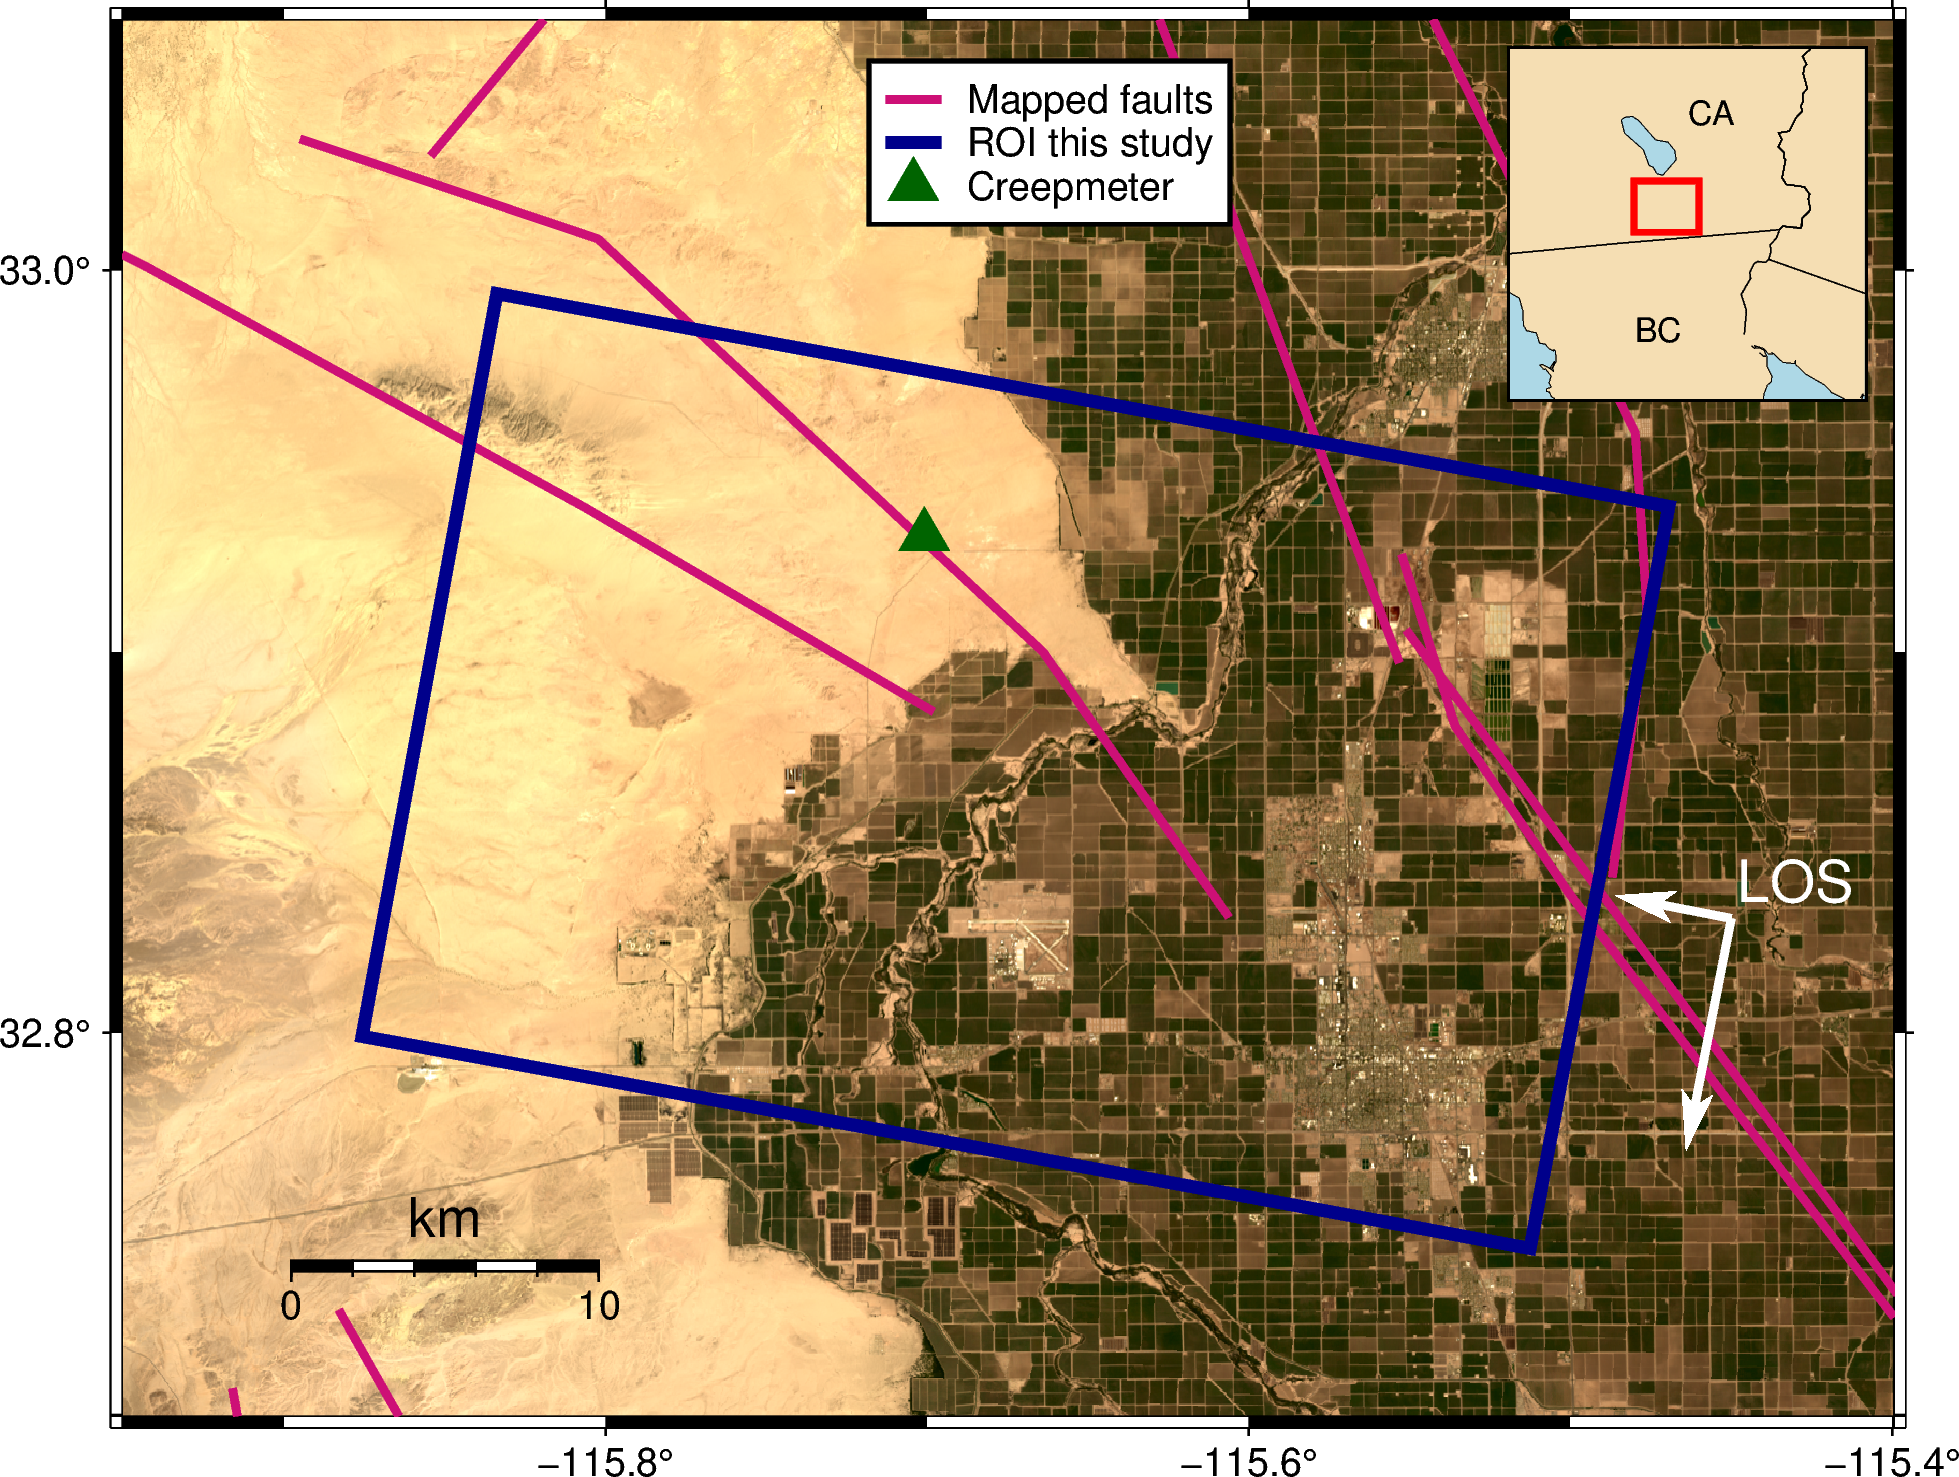

In [12]:
# Now make the figure. 

# define the region you want to plot on your map 
region_plot=  [-115.950285027,-115.399399084,32.6991998229,33.0655673364] 
# define the region for the inset map
region_inset= [-117,-114,31.5,34] 
# projection defines how wide we want the figure to be
proj = "M15c"

# start a figure
fig = pygmt.Figure() 
# make the coordinate formatting a single digit after decimal
pygmt.config(FORMAT_GEO_MAP="ddd.x") 
# define the background image
grid = 'basemap_optical_image.tif'

# plot the background image first
fig.grdimage(
    grid=grid,
    region=region_plot,
    projection=proj
    ) 

# plot coastlines, define lat/lon labels, annotations, and spacing
fig.coast(
    region=region_plot, 
    projection=proj,
    frame=["WSne", "xa0.2f0.1", "ya0.2f0.1"],
    #   labels on West and South borders, not on north and east
    #   a1- annotate every 1 degree 
    #   f0.5- space the black/white bars by 0.5 degrees
    borders=["1/thickest,black", "2/thick,black"], # 1=country borders, 2=state borders, a=all
    shorelines='thin,black',
    #   Use dcw to selectively highlight an area (country or state)
    #       dcw="US.CA",#"US.CA+gred",
    )

# plot the faults!
fig.plot(fault_poly,pen='2p,deeppink3',label='Mapped faults')

# plot outline of ROI
fig.plot(x=SH[:,0], y=SH[:,1],pen="3p,darkblue",label="ROI this study")

# plot arrow for Sentinel-1 azimuth and look directions
fig.plot(x=-115.45, y=32.83, style="v0.5c+e", pen="2p,white", fill='white', direction=[[259], [2]]) #[angle in degrees],[length]
fig.plot(x=-115.45, y=32.83, style="v0.5c+e", pen="2p,white", fill='white', direction=[[169], [1]])
fig.text(text='LOS', x=-115.43, y=32.84, font="14p,white", angle=0)

# plot creepmeter location
fig.plot(x=-115.7009,y=32.9303,style='t0.5c',fill='darkgreen',label="Creepmeter")

# add the scale bar
fig.basemap(
    map_scale=["f-115.85/32.74/20/10+lkm"], # +u adds units to the numbers, +lkm adds title to scale bar of "km"
    box="+gwhite+p1p" # NOT WORKING 
)

# add the inset map
with fig.inset(
    position="jTR+o0.25c/0.25c", 
    # j (lower case) = within map area, upper case = outside map area, TR=Top Right,
    # +w3c/3.1c - width/height of map, +o0.25c/0.25c is the offset from x and y corner position
    box="+pblack",
    # box="+pblack" - adds black outline around map
    region=region_inset,
    projection="M3c" # inset map width, 3cm
    ): 
    # plot the coastlines in the inset map
    fig.coast(
        land="wheat",
        borders=["a"], # add all state borders
        water="lightblue",
        shorelines="0.1p",
        area_thresh=500 # don't plot water bodies smaller than this (units km, I think)
        )
    # label the states shown
    fig.text(text="CA", x=-115.3, y=33.55)
    fig.text(text="BC", x=-115.75, y=32)
    rectangle = [[region_plot[0], region_plot[2], region_plot[1], region_plot[3]]]    
    fig.plot(data=rectangle, style="r+s", pen="1.5p,red")    
    # r- rectangle 
    # "+s" means that the first two columns are the lon/lat of the bottom left corner of the rectangle, 
    # and the last two columns the lon+lat of the uppper right corner.

#plot the legend in position you want and add white box around it
fig.legend(position="jTC+o0.35/0.35c",box="+gwhite+p1p")

# optional: save the figure.
#fig.savefig('SH_basemap.png',transparent=True)
fig.show()